# MNIST Test

In [37]:
import os
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets, transforms
import sklearn
import math
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from tqdm import tqdm
from PIL import Image, ImageDraw, ImageFont
from datetime import datetime

from src.data.datasets import sample_gaussian, plot_image
from src.models.models import (
    SimpleMLPVectorField,
    MLPVectorField,
    SimpleMLPVectorFieldND,
)
from src.solver import integrate

In [3]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name())

True
NVIDIA GeForce RTX 5050 Laptop GPU


### Data Acquisition


In [8]:
# build dataloader
def get_mnist_dataloader(batch_size=128, data_dir="src/data"):
    """Download MNIST and return a configured DataLoader."""

    # Transform: Convert PIL Image to Tensor and normalize to [-1, 1]
    # Normalizing makes the flow matching process significantly more stable
    transform = transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]
    )

    # Download training dataset
    train_dataset = datasets.MNIST(
        root=data_dir, train=True, download=True, transform=transform
    )

    # Setup DataLoader
    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, drop_last=True
    )

    return train_loader


def get_single_digit_mnist_dataloader(digit=8, batch_size=128, data_dir="src/data"):
    """Download MNIST and return a DataLoader filtering for a single digit."""

    transform = transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]
    )

    # Load full dataset
    full_dataset = datasets.MNIST(
        root=data_dir, train=True, download=True, transform=transform
    )

    # Filter indices where target equals the specified digit
    indices = (full_dataset.targets == digit).nonzero(as_tuple=True)[0]

    # Create a subset with only that digit
    single_digit_subset = torch.utils.data.Subset(full_dataset, indices)

    # Setup DataLoader
    train_loader = torch.utils.data.DataLoader(
        single_digit_subset, batch_size=batch_size, shuffle=True, drop_last=True
    )

    return train_loader

In [9]:
dl_train = get_single_digit_mnist_dataloader(digit=8, batch_size=128)

torch.Size([128, 1, 28, 28])


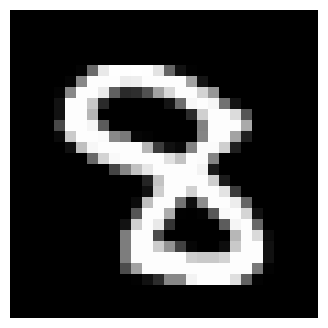

In [10]:
for batch in dl_train:
    images = batch[0]
    print(batch[0].shape)
    for i in images:
        plot_image(i)
        break
    break

torch.Size([1, 1, 28, 28])

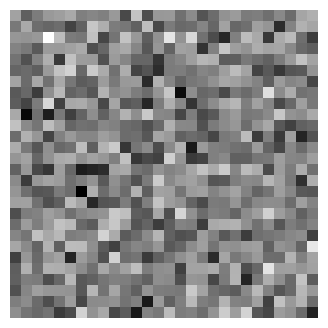

In [12]:
# testing the gaussian sampling in this high dimension

x0 = sample_gaussian(1, (1, 28, 28), "cpu")
plot_image(x0)
sample_gaussian(x0.shape[0], tuple(x0.shape[1:])).shape


## Training Procedure

In [13]:
def compute_conditional_flow(x1, device="cuda"):
    """Compute interpolations and targets using your custom sampler."""
    batch_size = x1.shape[0]

    # sampler for p0
    if len(x1.shape) == 4:
        # we expect shape (batch size, channel, height, width)
        x0 = sample_gaussian(batch_size, tuple(x1.shape[1:]), device=device)
    elif len(x1.shape) == 2:
        x0 = sample_gaussian(batch_size, dim=x1.shape[1], device=device)
    else:
        raise ValueError("Unknown shape for loss function.")

    # 2. Sample time steps t uniformly in [0, 1]
    t = torch.rand(batch_size, 1, device=device)

    # 3. Linear interpolation (path x_t)
    t_expanded = t.view(
        batch_size, *([1] * (len(x1.shape) - 1))
    )  # change shape / broadcasting
    xt = t_expanded * x1 + (1.0 - t_expanded) * x0

    # 4. Conditional vector field target (u_t)
    ut = x1 - x0

    return xt, t, ut


def cfm_loss(model, x1, device="cuda"):
    """Berechnet den mittleren quadratischen Fehler (MSE) zwischen vorhergesagtem

    und wahrem Vektorfeld.
    """
    xt, t, ut = compute_conditional_flow(x1, device)

    # the model tries to predict the vector field ut based on the position xt and time t
    vt = model(xt, t)

    # MSE Loss
    loss = torch.mean((vt - ut) ** 2)
    return loss


def train_step(model, optimizer, x1, loss_fn=cfm_loss, device="cuda"):
    """Performs a single training step: computes loss, backpropagates, and updates model parameters."""
    model.train()
    optimizer.zero_grad()
    loss = loss_fn(model, x1, device)
    loss.backward()
    optimizer.step()
    return loss.item()


def train_loop(
    model,
    optimizer,
    train_loader,
    n_epochs=1000,
    device="cuda",
    save_model=True,
    save_bestmodel=False,
    save_last_checkpoint=False,
    save_loss=True,
    plot_loss=True,
    folderpath="results",
):
    """Trains the model for a specified number of epochs."""
    loss_history = []
    for epoch in range(n_epochs):
        epoch_loss = 0
        n_batches = len(train_loader)
        for images, targets in train_loader:
            # only give the images, not the targets
            images = images.to(device)
            loss = train_step(model, optimizer, images, device=device)
            epoch_loss += loss.item() if hasattr(loss, "item") else loss
        # here simple avg-calculation since we drop the last, not-full batch
        epoch_avg_loss = epoch_loss / n_batches
        loss_history.append(epoch_avg_loss)

        if epoch == 0:
            print(f"Initial Loss: {loss:.4f}")
            min_loss = loss

        if loss < min_loss:
            min_loss = loss
            if save_bestmodel:
                store_model(model, folderpath=folderpath, filename="model_best")
        # elif (epoch + 1) % 100 == 0:
        #     print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {loss:.4f}")
        print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {loss:.4f}")

    if save_model:
        store_model(model, folderpath=folderpath, filename=None)
    if save_last_checkpoint:
        store_checkpoint(
            model,
            optimizer=optimizer,
            epoch=n_epochs,
            folderpath=folderpath,
            filename=None,
        )
    if save_loss:
        loss_path = os.path.join(folderpath, "loss_history")
        # save as pytorch file for later loading
        torch.save(loss_history, f"{loss_path}.pth")
        # csv with numpy
        loss_np = np.array(loss_history)
        np.savetxt(f"{loss_path}.csv", loss_np, fmt="%.6f")

        print(f"Loss history saved to {folderpath}")

    if plot_loss:
        fig, ax = plt.subplots(figsize=(5, 4))
        ax.plot(loss_history)
        ax.set_title("Training Loss")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("MSE Loss")
        fig.savefig(
            os.path.join(folderpath, "loss_history.png"), dpi=300, bbox_inches="tight"
        )
        plt.close()
        os.startfile(os.path.join(folderpath, "loss_history.png"))

    return loss_history


def store_model(model, folderpath="results", filename=None):
    """Saves the model's state dictionary to a file."""

    daystamp = datetime.now().strftime("%m-%d-%y")

    if filename is None:
        filename = f"model_{daystamp}.pth"
    else:
        filename = f"{filename}_{daystamp}.pth"

    path = os.path.join(folderpath, filename)

    torch.save(model.state_dict(), path)
    print(f"Model saved to {path}")


def store_checkpoint(
    model, optimizer=None, epoch=None, folderpath="results", filename=None
):
    """Saves the model and optimizer state dictionaries to a file."""

    daystamp = datetime.now().strftime("%m-%d-%y")

    if filename is None:
        filename = f"model_{daystamp}.pth"
    else:
        filename = f"{filename}_{daystamp}.pth"

    path = os.path.join(folderpath, filename)

    checkpoint = {
        "model_state_dict": model.state_dict(),
    }
    if optimizer is not None:
        checkpoint["optimizer_state_dict"] = optimizer.state_dict()
    if epoch is not None:
        checkpoint["epoch"] = epoch

    torch.save(checkpoint, path)
    print(f"Model saved to {path}")

## Testing

In [33]:
model = SimpleMLPVectorFieldND(28, 128).to("cuda")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_history = train_loop(
    model,
    optimizer,
    dl_train,
    100,
    device="cuda",
    save_model=False,
    save_loss=False,
    plot_loss=False,
)

Initial Loss: 1.2622
Epoch 1/100, Loss: 1.2622
Epoch 2/100, Loss: 1.2467
Epoch 3/100, Loss: 1.2321
Epoch 4/100, Loss: 1.2270
Epoch 5/100, Loss: 1.2369
Epoch 6/100, Loss: 1.2453
Epoch 7/100, Loss: 1.2394
Epoch 8/100, Loss: 1.2312
Epoch 9/100, Loss: 1.2448
Epoch 10/100, Loss: 1.2377
Epoch 11/100, Loss: 1.2454
Epoch 12/100, Loss: 1.2410
Epoch 13/100, Loss: 1.2298
Epoch 14/100, Loss: 1.2268
Epoch 15/100, Loss: 1.2428
Epoch 16/100, Loss: 1.2260
Epoch 17/100, Loss: 1.2398
Epoch 18/100, Loss: 1.2300
Epoch 19/100, Loss: 1.2365
Epoch 20/100, Loss: 1.2235
Epoch 21/100, Loss: 1.2375
Epoch 22/100, Loss: 1.2218
Epoch 23/100, Loss: 1.2320
Epoch 24/100, Loss: 1.2338
Epoch 25/100, Loss: 1.2293
Epoch 26/100, Loss: 1.2320
Epoch 27/100, Loss: 1.2332
Epoch 28/100, Loss: 1.2321
Epoch 29/100, Loss: 1.2337
Epoch 30/100, Loss: 1.2315
Epoch 31/100, Loss: 1.2364
Epoch 32/100, Loss: 1.2269
Epoch 33/100, Loss: 1.2404
Epoch 34/100, Loss: 1.2236
Epoch 35/100, Loss: 1.2396
Epoch 36/100, Loss: 1.2217
Epoch 37/100, Lo

Integrating: 100%|██████████| 100/100 [00:00<00:00, 1127.93it/s]


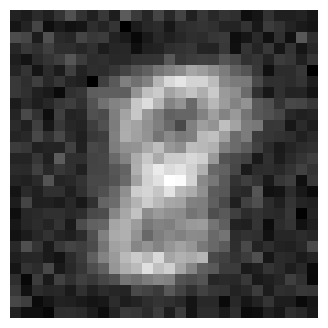

In [36]:
x0 = sample_gaussian(1, (1, 28, 28), device="cuda")
x_final, trajectories = integrate(model, x0, n_steps=100, h=1e-1, integrator="rk4")
plot_image(x_final.detach().cpu())

## Time Embedding

In [60]:
np.exp(-9)

np.float64(0.00012340980408667956)

In [ ]:
# Compute frequency frequencies
d = 4
t = torch.arange(d)[:, None]
print(t.shape)
half_dim = d // 2
device = "cpu"
emb = math.log(1000) / (half_dim - 1)
emb = torch.exp(
    torch.arange(half_dim, device=device) * -emb
)  # creates an array between 0 and 1e-3
print(emb)

# # Broadcast and compute sin/cos
emb = t * emb[None, :]
print(emb)
# emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
emb

torch.Size([4, 1])
tensor([1.0000e+00, 1.0000e-03])
tensor([[0.0000e+00, 0.0000e+00],
        [1.0000e+00, 1.0000e-03],
        [2.0000e+00, 2.0000e-03],
        [3.0000e+00, 3.0000e-03]])


tensor([[0.0000e+00, 0.0000e+00],
        [1.0000e+00, 1.0000e-03],
        [2.0000e+00, 2.0000e-03],
        [3.0000e+00, 3.0000e-03]])